In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cloudpickle as pickle
import matplotlib_inline.backend_inline

matplotlib_inline.backend_inline.set_matplotlib_formats("retina")

In [2]:
with open("forward_model_2d_001.pkl", "rb") as f:
    model = pickle.load(f)


# Index for the single earthquake:
eq_t_idx = 50

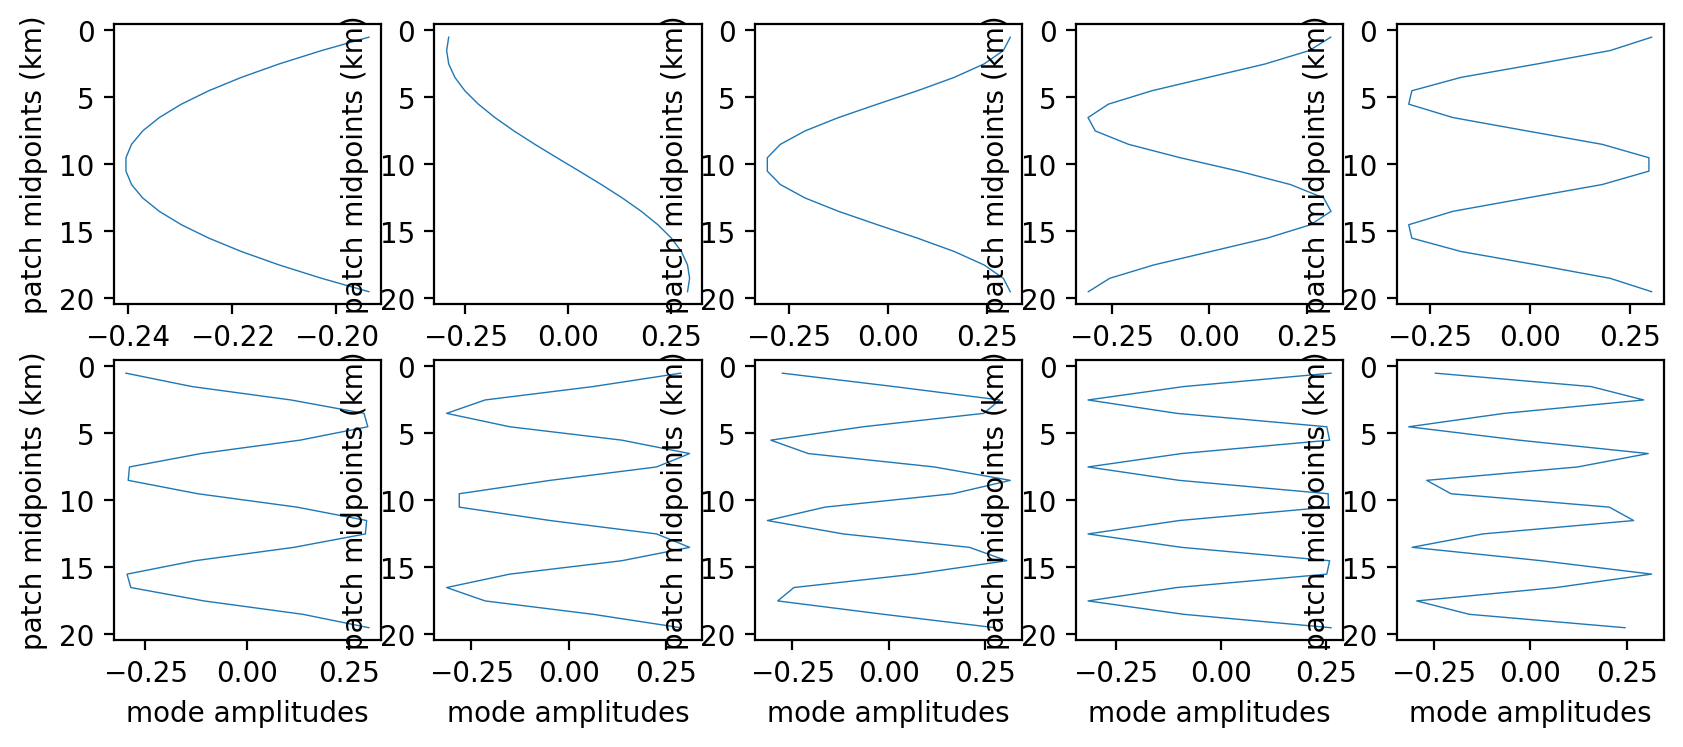

In [ ]:
# Plot modes
plt.figure(figsize=(10, 4))
for i in range(model.n_fault_patch_modes):
    plt.subplot(2, 5, i + 1)
    plt.plot(
        model.fault_patch_modes[0, :, i],
        model.fault_patch_midpoints[0, :, 1] / 1e3,
        label=f"{i}",
        linewidth=0.5,
    )
    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel("mode amplitudes")
    plt.ylabel("patch midpoints (km)")
    plt.gca().invert_yaxis()


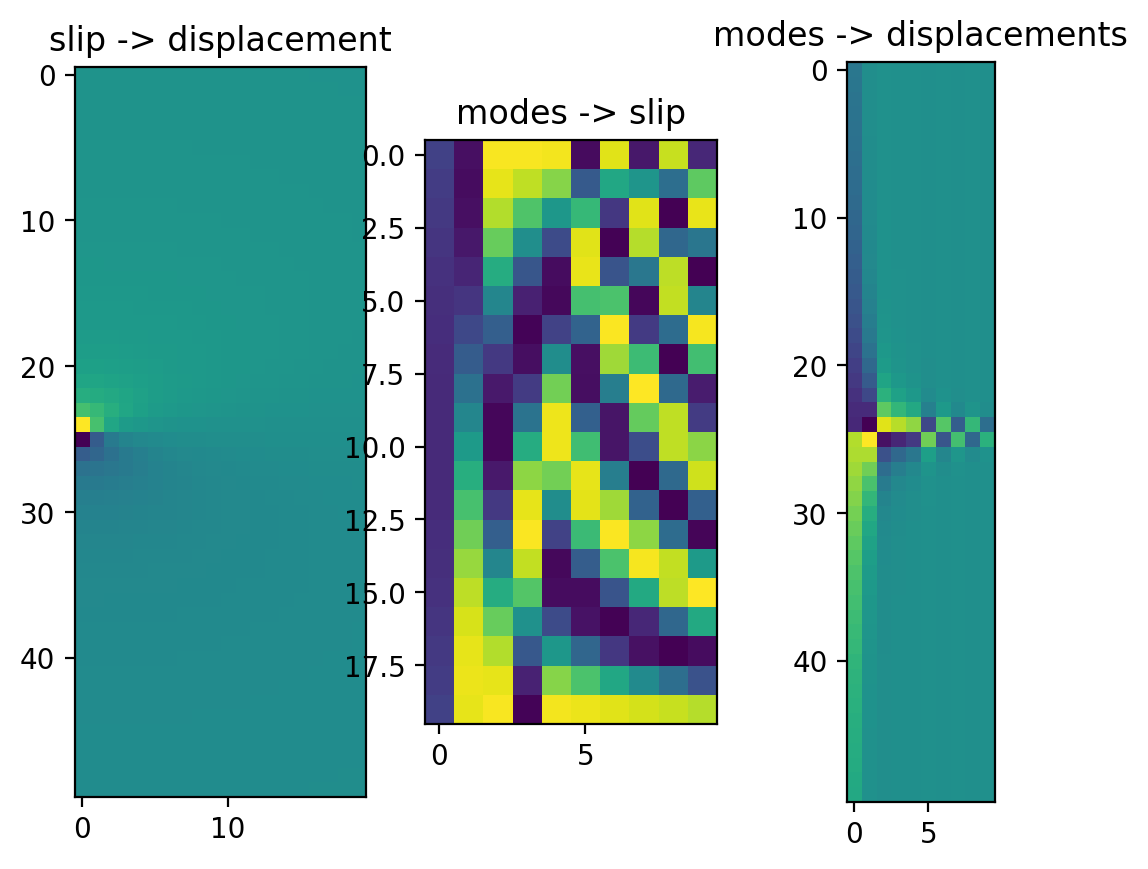

In [ ]:
# Build linear operator
plt.figure()
plt.subplot(1, 3, 1)
plt.title("slip -> displacement")
plt.imshow(model.fault_patch_partials[:, 0, :])

plt.subplot(1, 3, 2)
plt.title("modes -> slip")
plt.imshow(model.fault_patch_modes[0, :, :])

operator = model.fault_patch_partials[:, 0, :] @ model.fault_patch_modes[0, :, :]
plt.subplot(1, 3, 3)
plt.title("modes -> displacements")
plt.imshow(operator)
plt.show()


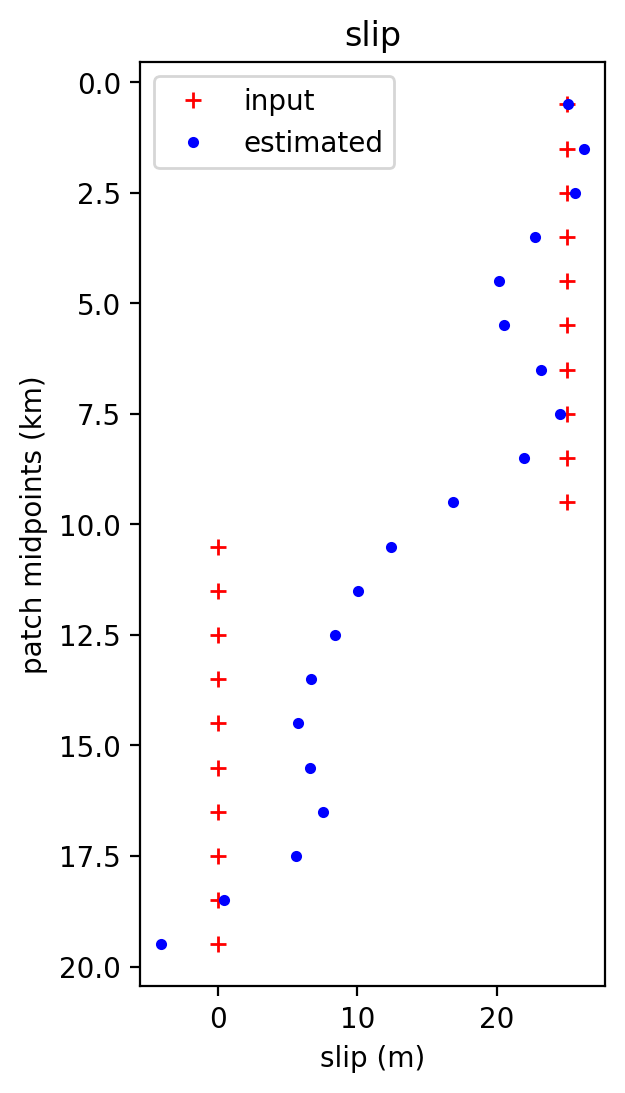

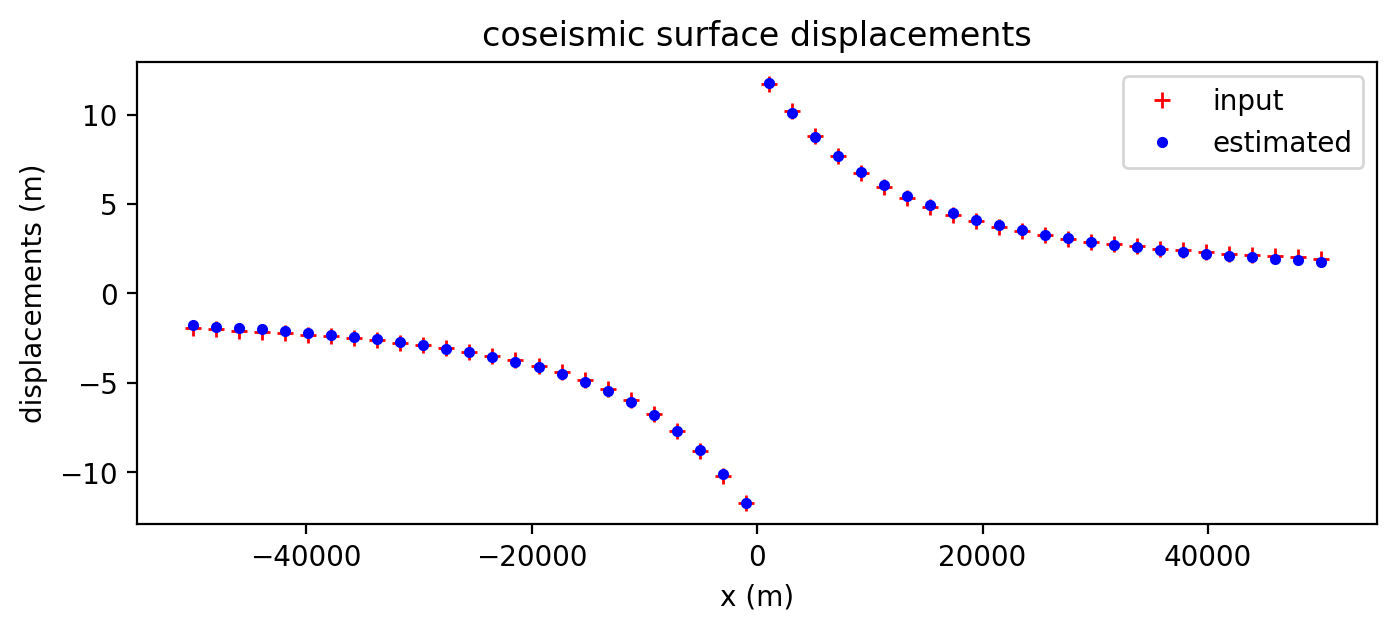

In [ ]:
# Solve with ridge regression
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1e-8, random_state=0, positive=True)
ridge.fit(operator, model.obs_vel_mat[:, eq_t_idx])
modes_estimated = ridge.coef_

# Convert estimated modes to fault slip
slip_estimated = model.fault_patch_modes[0, :, :] @ modes_estimated

# Calculate forward displacements
obs_vels_forward = model.fault_patch_partials[:, 0, :] @ slip_estimated

# Plot true and estimated coseismic fault slip
plt.figure(figsize=(3, 6))
plt.title("slip")
plt.plot(
    model.fault_patch_slip_rates[eq_t_idx, 0, :],
    model.fault_patch_midpoints[0, :, 1] / 1e3,
    "r+",
    label="input",
)
plt.plot(
    -slip_estimated,  #  NOTE: I don't understand why I need a negative sign here...?
    model.fault_patch_midpoints[0, :, 1] / 1e3,
    "b.",
    label="estimated",
)
plt.legend()
plt.gca().invert_yaxis()
plt.xlabel("slip (m)")
plt.ylabel("patch midpoints (km)")
plt.show()

# Plot true and predicted surface displacements
plt.figure(figsize=(8, 3))
plt.title("coseismic surface displacements")
plt.plot(model.obs_x, model.obs_vel_mat[:, eq_t_idx], "r+", label="input")
plt.plot(model.obs_x, obs_vels_forward, "b.", label="estimated")
plt.xlabel("x (m)")
plt.ylabel("displacements (m)")
plt.legend()
plt.show()